In [34]:
# Start .venv in terminal
# ----------------------
# .\.venv\Scripts\activate
# ----------------------

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import random
from datetime import datetime

from Data_Handling import fetch_alpaca_vbt_data

In [36]:
# -----------------------
# 1) Reproducibility (best-effort)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# -----------------------
# 2) Load your data
df = fetch_alpaca_vbt_data(symbol="SPY", start= "2025-09-01", end= "2025-10-01", timeframe_unit="Minute", multiplier=1)

X_all shape: (16897, 100, 5) y_all shape: (16897,)


c:\[] Mario\[] Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


370/370 - 13s - 35ms/step - loss: 0.0321 - mae: 0.0960 - val_loss: 0.0058 - val_mae: 0.0664
Epoch 2/50


370/370 - 10s - 26ms/step - loss: 0.0063 - mae: 0.0559 - val_loss: 0.0015 - val_mae: 0.0316
Epoch 3/50
370/370 - 10s - 28ms/step - loss: 0.0052 - mae: 0.0515 - val_loss: 0.0057 - val_mae: 0.0682
Epoch 4/50
370/370 - 10s - 26ms/step - loss: 0.0046 - mae: 0.0481 - val_loss: 0.0069 - val_mae: 0.0759
Epoch 5/50
370/370 - 11s - 30ms/step - loss: 0.0040 - mae: 0.0451 - val_loss: 0.0077 - val_mae: 0.0802
Epoch 6/50
370/370 - 10s - 28ms/step - loss: 0.0037 - mae: 0.0427 - val_loss: 0.0051 - val_mae: 0.0669
Epoch 7/50
370/370 - 11s - 30ms/step - loss: 0.0034 - mae: 0.0414 - val_loss: 0.0144 - val_mae: 0.1107
Epoch 8/50
370/370 - 11s - 29ms/step - loss: 0.0034 - mae: 0.0407 - val_loss: 0.0255 - val_mae: 0.1483
Epoch 9/50
370/370 - 10s - 27ms/step - loss: 0.0028 - mae: 0.0373 - val_loss: 0.0148 - val_mae: 0.1111
Epoch 10/50
370/370 - 11s - 29ms/step - loss: 0.0026 - mae: 0.0354 - val_loss: 0.0160 - val_mae: 0.1166
Epoch 11/50
370/370 - 21s - 57ms/step - loss: 0.0027 - mae: 0.0357 - val_loss: 0.02

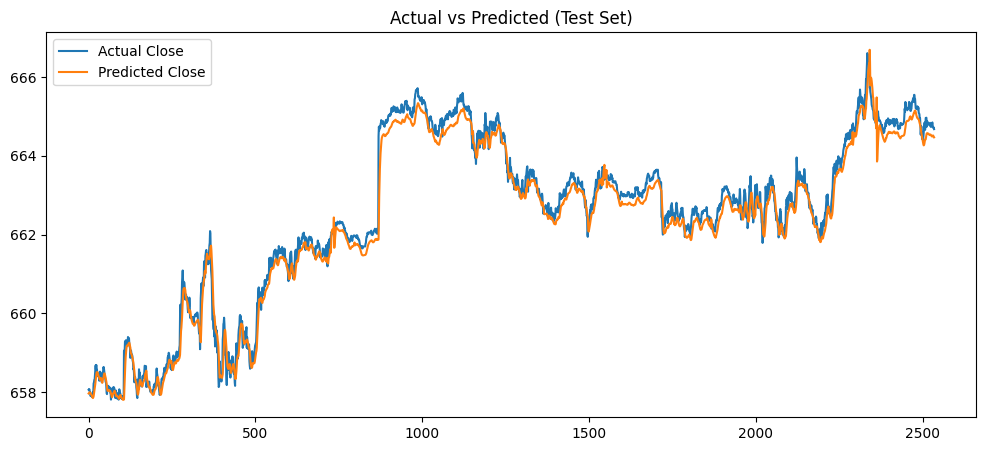

In [37]:
# -----------------------
# 3) Choose window and horizon
window_size = 100   # use past 60 bars (e.g., minutes or days)
horizon = 1        # predict 1 step ahead

# -----------------------
# 4) Feature creation (use OHLCV)
# Ensure df has the expected columns from Alpaca
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[-1] for col in df.columns]  # flatten like ('field', 'Open') → 'Open'
df.columns = [c.lower() for c in df.columns]
features = ['open', 'high', 'low', 'close', 'volume']
df = df[features].astype(float)
data = df.values

# -----------------------
# 5) Create sliding windows
def make_windows(data, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - (horizon - 1)):
        X.append(data[i:i+window_size])
        # Target is future close (index 3)
        y.append(data[i + window_size + horizon - 1, 3])
    return np.array(X), np.array(y)

X_all, y_all = make_windows(data, window_size, horizon)
print("X_all shape:", X_all.shape, "y_all shape:", y_all.shape)  # (samples, window_size, 5)

# -----------------------
# 6) Chronological train/val/test split
train_frac = 0.7
val_frac = 0.15
n = len(X_all)
n_train = int(n * train_frac)
n_val = int(n * (train_frac + val_frac))

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_val], y_all[n_train:n_val]
X_test,  y_test  = X_all[n_val:], y_all[n_val:]

# -----------------------
# 7) Scale features — fit on training only
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_flat)

def scale_X(X, scaler):
    n_samples = X.shape[0]
    return scaler.transform(X.reshape(-1, X.shape[-1])).reshape(n_samples, X.shape[1], X.shape[2])

X_train_s = scale_X(X_train, scaler)
X_val_s   = scale_X(X_val, scaler)
X_test_s  = scale_X(X_test, scaler)

# Scale targets (y) separately
target_scaler = StandardScaler()
target_scaler.fit(y_train.reshape(-1,1))
y_train_s = target_scaler.transform(y_train.reshape(-1,1)).reshape(-1)
y_val_s   = target_scaler.transform(y_val.reshape(-1,1)).reshape(-1)
y_test_s  = target_scaler.transform(y_test.reshape(-1,1)).reshape(-1)

# -----------------------
# 8) Build the LSTM model
model = Sequential([
    LSTM(64, input_shape=(window_size, X_train_s.shape[-1]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # regression output (scaled)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss')
]

# -----------------------
# 9) Train
history = model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)

# -----------------------
# 10) Evaluate and invert scaling
y_pred_s = model.predict(X_test_s).reshape(-1,1)
y_pred = target_scaler.inverse_transform(y_pred_s).reshape(-1)
y_true = y_test.reshape(-1)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

print(f"Test RMSE: {rmse:.6f}, MAE: {mae:.6f}, MAPE: {mape:.3f}%")

# Plot actual vs predicted
plt.figure(figsize=(12,5))
plt.plot(y_true, label='Actual Close')
plt.plot(y_pred, label='Predicted Close')
plt.legend()
plt.title("Actual vs Predicted (Test Set)")
plt.show()


Directional Accuracy: 48.26%
Value Hit Rate (±0.1% tolerance): 97.71%
Hits: 2477, Misses: 58


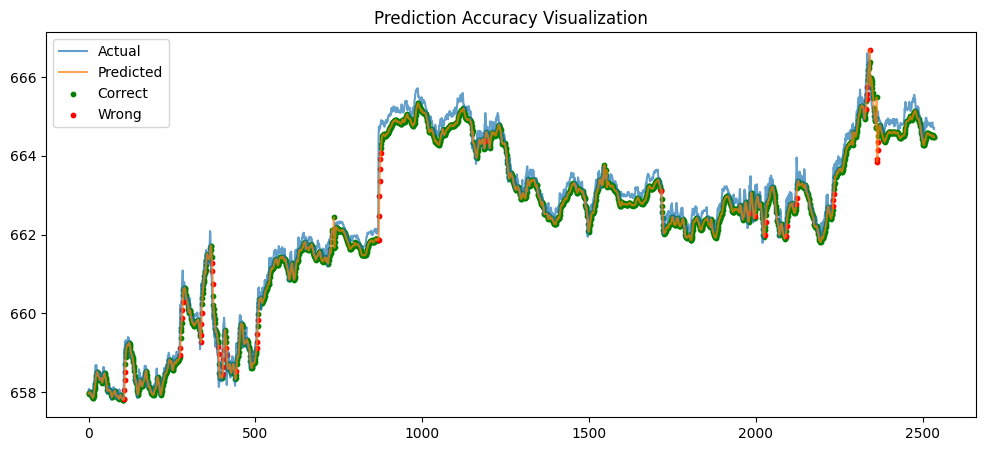

In [40]:
# -----------------------
# Evaluate directional accuracy
direction_true = np.sign(np.diff(y_true))        # +1 for up, -1 for down, 0 for flat
direction_pred = np.sign(np.diff(y_pred))

correct_directions = np.sum(direction_true == direction_pred)
total_directions = len(direction_true)
direction_accuracy = correct_directions / total_directions * 100

print(f"Directional Accuracy: {direction_accuracy:.2f}%")

# -----------------------
# Value-based accuracy with tolerance
tolerance = 0.001  # 0.1% margin
hit_count = 0
miss_count = 0

for actual, pred in zip(y_true, y_pred):
    if abs(pred - actual) / actual <= tolerance:
        hit_count += 1
    else:
        miss_count += 1

hit_rate = hit_count / (hit_count + miss_count) * 100
print(f"Value Hit Rate (±0.1% tolerance): {hit_rate:.2f}%")
print(f"Hits: {hit_count}, Misses: {miss_count}")

plt.figure(figsize=(12,5))
plt.plot(y_true, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.scatter(
    np.arange(len(y_true))[abs((y_true - y_pred)/y_true) <= tolerance],
    y_pred[abs((y_true - y_pred)/y_true) <= tolerance],
    color='green', label='Correct', s=10
)
plt.scatter(
    np.arange(len(y_true))[abs((y_true - y_pred)/y_true) > tolerance],
    y_pred[abs((y_true - y_pred)/y_true) > tolerance],
    color='red', label='Wrong', s=10
)
plt.legend()
plt.title("Prediction Accuracy Visualization")
plt.show()
